# TabPFN Regression

Small-data sanity-check model using the same strict random train/test split and the same target-transform evaluation protocol as the other regressors. This notebook intentionally uses the original `ml_ready` dataset without physical features by default, so it can be compared against XGBoost/CatBoost/ExtraTrees baseline runs.

In [1]:
from __future__ import annotations

import os

# Local notebook convenience: token is intentionally set here by user request.
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_mpWYH4-X1rTLNx6fR6nw1QfFVqo94kU21iaZEso2Gcg"
print("TABPFN_TOKEN is set for this notebook session.")

import json
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import PowerTransformer

try:
    from tabpfn import TabPFNRegressor
except ImportError as exc:
    raise ImportError(
        "TabPFN is not installed in this environment. Install it before running this notebook, e.g.\n"
        "conda run -n BES pip install tabpfn"
    ) from exc

RANDOM_STATE = 42
N_SPLITS = 5
TARGET_COL = "max_power_density_w_m2"
SPLIT_NAME = "random_split"
TARGET_TRANSFORM = "yeo-johnson"
TARGET_TRANSFORM_OPTIONS = {"raw", "log1p", "cuberoot", "yeo-johnson", "box-cox"}
if TARGET_TRANSFORM not in TARGET_TRANSFORM_OPTIONS:
    raise ValueError(f"Unsupported TARGET_TRANSFORM={TARGET_TRANSFORM!r}")

# Use "cuda" on the server if TabPFN and torch can see a GPU. Use "cpu" for reproducible CPU runs.
DEVICE = "auto"
TABPFN_PARAMS = {}
PERMUTATION_REPEATS = 5

BASE_DIR = Path.cwd()

# Baseline comparison: original 5D dataset without physical features.
RUN_NAME = "pls_3d_iterative_extra_trees"
RUN_MODE = "no_tuning"
DATA_DIR = BASE_DIR / "ml_ready" / RUN_NAME
RESULT_DIR = BASE_DIR / "model_results" / "tabpfn" / RUN_NAME / f"{TARGET_TRANSFORM}_{SPLIT_NAME}_{RUN_MODE}"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

train_df = pd.read_csv(DATA_DIR / "train_features.csv", encoding="utf-8-sig")
test_df = pd.read_csv(DATA_DIR / "test_features.csv", encoding="utf-8-sig")
train_source = pd.read_csv(DATA_DIR / "train_source_rows.csv", encoding="utf-8-sig")
test_source = pd.read_csv(DATA_DIR / "test_source_rows.csv", encoding="utf-8-sig")

feature_cols = [col for col in train_df.columns if col != TARGET_COL]
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()

print(f"Split strategy    : {SPLIT_NAME}")
print(f"Run mode          : {RUN_MODE}")
print(f"Target transform  : {TARGET_TRANSFORM}")
print(f"TabPFN device     : {DEVICE}")
print(f"Train features    : {X_train.shape}")
print(f"Test features     : {X_test.shape}")
print(f"Missing values    : train={int(train_df.isna().sum().sum())}, test={int(test_df.isna().sum().sum())}")
print(f"Train y skew raw  : {float(y_train.skew()):.4f}")
print(f"Result directory  : {RESULT_DIR}")

TABPFN_TOKEN is set for this notebook session.


c:\Users\shimk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Split strategy    : random_split
Run mode          : no_tuning
Target transform  : yeo-johnson
TabPFN device     : auto
Train features    : (83, 18)
Test features     : (15, 18)
Missing values    : train=0, test=0
Train y skew raw  : 2.1816
Result directory  : C:\Users\shimk\Downloads\BES_061726\model_results\tabpfn\pls_3d_iterative_extra_trees\yeo-johnson_random_split_no_tuning


In [2]:
TEXT_VALUE_COLUMNS = ["substrate_type", "anode_material", "cathode_material"]
NUMERIC_FEATURES = [
    "initial_conc_g_cod_l",
    "anode_surface_area_m2",
    "anolyte_volume_ml",
    "cathode_surface_area_m2",
    "catholyte_volume_ml",
    "pH",
    "temperature_c",
    "anode_S_V_ratio_m2_m3",
    "cathode_S_V_ratio_m2_m3",    
]

def input_signature(df: pd.DataFrame) -> pd.Series:
    stable = df[TEXT_VALUE_COLUMNS + NUMERIC_FEATURES].copy()
    for column in TEXT_VALUE_COLUMNS:
        stable[column] = stable[column].astype(str).str.strip().str.lower()
    for column in NUMERIC_FEATURES:
        stable[column] = stable[column].map(lambda value: "<NA>" if pd.isna(value) else f"{float(value):.12g}")
    return stable.astype(str).agg("||".join, axis=1)

def fit_target_transformer(y, method: str):
    y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
    if method == "box-cox":
        if np.any(y_arr <= 0):
            raise ValueError("Box-Cox requires strictly positive target values.")
        return PowerTransformer(method="box-cox", standardize=True).fit(y_arr)
    if method == "yeo-johnson":
        return PowerTransformer(method="yeo-johnson", standardize=True).fit(y_arr)
    return None

def transform_target(y, method: str, transformer=None) -> np.ndarray:
    y_arr = np.asarray(y, dtype=float)
    if method == "raw":
        return y_arr
    if method == "log1p":
        return np.log1p(y_arr)
    if method == "cuberoot":
        return np.cbrt(y_arr)
    return transformer.transform(y_arr.reshape(-1, 1)).ravel()

def inverse_transform_target(y_transformed, method: str, transformer=None) -> np.ndarray:
    y_arr = np.asarray(y_transformed, dtype=float)
    if method == "raw":
        return y_arr
    if method == "log1p":
        return np.expm1(y_arr)
    if method == "cuberoot":
        return np.power(y_arr, 3)
    return transformer.inverse_transform(y_arr.reshape(-1, 1)).ravel()

def regression_metrics(y_true, y_pred) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }

def clipped_regression_metrics(y_true, y_pred) -> dict[str, float]:
    clipped = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {f"clipped_{key}": value for key, value in regression_metrics(y_true, clipped).items()}

def make_model() -> TabPFNRegressor:
    kwargs = dict(TABPFN_PARAMS)
    if DEVICE != "auto":
        kwargs["device"] = DEVICE
    try:
        return TabPFNRegressor(**kwargs)
    except TypeError:
        kwargs.pop("device", None)
        return TabPFNRegressor(**kwargs)

def fit_predict_original_scale(X_fit, y_fit, X_eval):
    target_transformer = fit_target_transformer(y_fit, TARGET_TRANSFORM)
    y_fit_model = transform_target(y_fit, TARGET_TRANSFORM, target_transformer)
    model = make_model()
    model.fit(X_fit.to_numpy(dtype=np.float32), y_fit_model.astype(np.float32))
    pred_model_scale = model.predict(X_eval.to_numpy(dtype=np.float32))
    pred = inverse_transform_target(pred_model_scale, TARGET_TRANSFORM, target_transformer)
    return model, target_transformer, pred

train_input_signatures = input_signature(train_source)
test_input_signatures = input_signature(test_source)
input_signature_overlap = set(train_input_signatures).intersection(set(test_input_signatures))

In [3]:
fold_records = []
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for fold, (fit_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_fit = X_train.iloc[fit_idx]
    y_fit = y_train.iloc[fit_idx]
    X_val = X_train.iloc[val_idx]
    y_val = y_train.iloc[val_idx]

    _, _, val_pred = fit_predict_original_scale(X_fit, y_fit, X_val)
    metrics = regression_metrics(y_val, val_pred)
    clipped_metrics = clipped_regression_metrics(y_val, val_pred)
    fold_records.append({"fold": fold, **metrics, **clipped_metrics})

fold_metrics = pd.DataFrame(fold_records)
fold_metrics.to_csv(RESULT_DIR / "fold_metrics.csv", index=False, encoding="utf-8-sig")

final_target_transformer = fit_target_transformer(y_train, TARGET_TRANSFORM)
y_train_model = transform_target(y_train, TARGET_TRANSFORM, final_target_transformer)
final_model = make_model()
final_model.fit(X_train.to_numpy(dtype=np.float32), y_train_model.astype(np.float32))
joblib.dump(final_model, RESULT_DIR / "tabpfn_model.joblib")
if final_target_transformer is not None:
    joblib.dump(final_target_transformer, RESULT_DIR / "target_power_transformer.joblib")

print("CV fold metrics:")
display(fold_metrics)
print("Input-signature overlap audit:", len(input_signature_overlap))

CV fold metrics:


,fold,mae,rmse,r2,clipped_mae,clipped_rmse,clipped_r2
0,1,0.168687,0.299442,0.018448,0.168687,0.299442,0.018448
1,2,0.125717,0.199733,0.264977,0.125717,0.199733,0.264977
2,3,0.109530,0.179154,0.586501,0.109530,0.179154,0.586501
3,4,0.181807,0.356083,0.313767,0.181807,0.356083,0.313767
4,5,0.135568,0.203036,0.523922,0.135568,0.203036,0.523922


Input-signature overlap audit: 0


In [4]:
train_pred_model_scale = final_model.predict(X_train.to_numpy(dtype=np.float32))
test_pred_model_scale = final_model.predict(X_test.to_numpy(dtype=np.float32))
train_pred = inverse_transform_target(train_pred_model_scale, TARGET_TRANSFORM, final_target_transformer)
test_pred = inverse_transform_target(test_pred_model_scale, TARGET_TRANSFORM, final_target_transformer)
train_pred_clipped = np.clip(train_pred, 0, None)
test_pred_clipped = np.clip(test_pred, 0, None)

train_metrics = regression_metrics(y_train, train_pred)
test_metrics = regression_metrics(y_test, test_pred)
train_clipped_metrics = clipped_regression_metrics(y_train, train_pred)
test_clipped_metrics = clipped_regression_metrics(y_test, test_pred)
cv_summary = {
    "best_trial": None,
    "best_cv_mean_mae": float(fold_metrics["mae"].mean()),
    "best_cv_std_mae": float(fold_metrics["mae"].std(ddof=1)),
    "best_cv_mean_rmse": float(fold_metrics["rmse"].mean()),
    "best_cv_mean_r2": float(fold_metrics["r2"].mean()),
    "best_cv_mean_clipped_mae": float(fold_metrics["clipped_mae"].mean()),
    "best_cv_mean_clipped_rmse": float(fold_metrics["clipped_rmse"].mean()),
    "best_cv_mean_clipped_r2": float(fold_metrics["clipped_r2"].mean()),
}
metrics_payload = {
    "run_name": RUN_NAME,
    "split_strategy": SPLIT_NAME,
    "run_mode": RUN_MODE,
    "target": TARGET_COL,
    "target_transform": TARGET_TRANSFORM,
    "metric_scale": "original_w_m2_after_inverse_transform",
    "objective_metric": "no_hyperparameter_tuning_random_kfold_cv_reported_only",
    "n_splits": N_SPLITS,
    "random_state": RANDOM_STATE,
    "model_family": "tabpfn",
    "tabpfn_device": DEVICE,
    "input_signature_overlap_audit": int(len(input_signature_overlap)),
    "cv": cv_summary,
    "train": train_metrics,
    "train_clipped_at_zero_for_report": train_clipped_metrics,
    "test": test_metrics,
    "test_clipped_at_zero_for_report": test_clipped_metrics,
    "best_params": TABPFN_PARAMS,
}
with open(RESULT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

train_predictions = train_source.copy()
train_predictions["actual"] = y_train.to_numpy()
train_predictions["predicted"] = train_pred
train_predictions["predicted_clipped_at_zero"] = train_pred_clipped
train_predictions["residual"] = train_predictions["actual"] - train_predictions["predicted"]
train_predictions["residual_clipped_at_zero"] = train_predictions["actual"] - train_predictions["predicted_clipped_at_zero"]
train_predictions.to_csv(RESULT_DIR / "train_predictions.csv", index=False, encoding="utf-8-sig")

test_predictions = test_source.copy()
test_predictions["actual"] = y_test.to_numpy()
test_predictions["predicted"] = test_pred
test_predictions["predicted_clipped_at_zero"] = test_pred_clipped
test_predictions["residual"] = test_predictions["actual"] - test_predictions["predicted"]
test_predictions["residual_clipped_at_zero"] = test_predictions["actual"] - test_predictions["predicted_clipped_at_zero"]
test_predictions.to_csv(RESULT_DIR / "test_predictions.csv", index=False, encoding="utf-8-sig")

print("CV summary:")
print(json.dumps(cv_summary, indent=2))
print("\nTrain metrics, original scale, unclipped:")
print(json.dumps(train_metrics, indent=2))
print("\nRandom holdout test metrics, original scale, unclipped:")
print(json.dumps(test_metrics, indent=2))
print("\nRandom holdout test metrics, clipped at zero for report only:")
print(json.dumps(test_clipped_metrics, indent=2))

CV summary:
{
  "best_trial": null,
  "best_cv_mean_mae": 0.14426164454638038,
  "best_cv_std_mae": 0.030133130807607274,
  "best_cv_mean_rmse": 0.2474899063841029,
  "best_cv_mean_r2": 0.34152293928637867,
  "best_cv_mean_clipped_mae": 0.14426164454638038,
  "best_cv_mean_clipped_rmse": 0.2474899063841029,
  "best_cv_mean_clipped_r2": 0.34152293928637867
}

Train metrics, original scale, unclipped:
{
  "mae": 0.03974566727316618,
  "rmse": 0.08925977309204844,
  "r2": 0.9203498420952443
}

Random holdout test metrics, original scale, unclipped:
{
  "mae": 0.06131224965984225,
  "rmse": 0.07958192953377578,
  "r2": 0.9102216556440376
}

Random holdout test metrics, clipped at zero for report only:
{
  "clipped_mae": 0.06131224965984225,
  "clipped_rmse": 0.07958192953377578,
  "clipped_r2": 0.9102216556440376
}


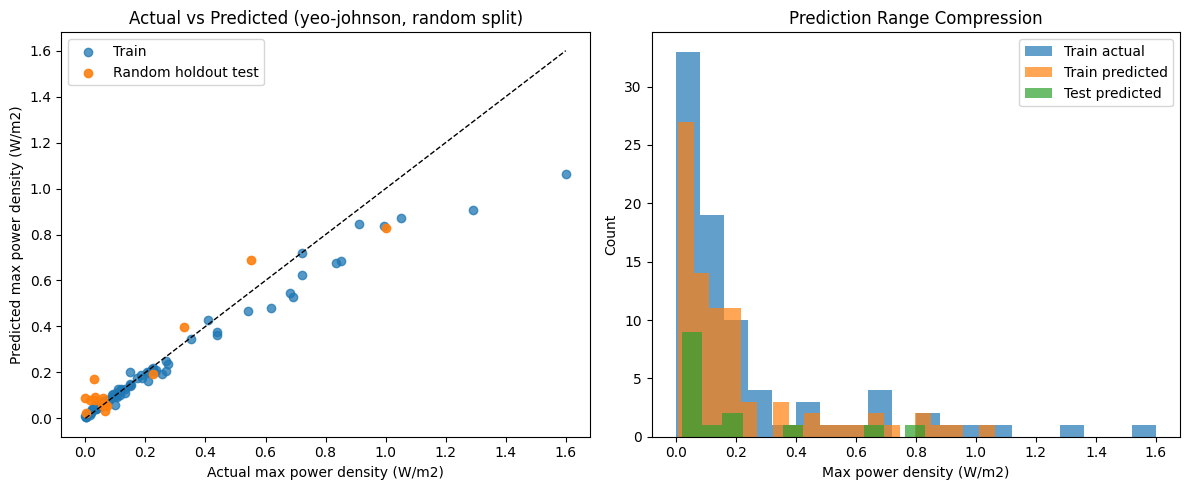

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, train_pred, alpha=0.75, label="Train")
axes[0].scatter(y_test, test_pred, alpha=0.9, label="Random holdout test")
min_value = float(min(y_train.min(), y_test.min(), train_pred.min(), test_pred.min()))
max_value = float(max(y_train.max(), y_test.max(), train_pred.max(), test_pred.max()))
axes[0].plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black", linewidth=1)
axes[0].set_xlabel("Actual max power density (W/m2)")
axes[0].set_ylabel("Predicted max power density (W/m2)")
axes[0].set_title(f"Actual vs Predicted ({TARGET_TRANSFORM}, random split)")
axes[0].legend()

axes[1].hist(y_train, bins=20, alpha=0.7, label="Train actual")
axes[1].hist(train_pred, bins=20, alpha=0.7, label="Train predicted")
axes[1].hist(test_pred, bins=12, alpha=0.7, label="Test predicted")
axes[1].set_xlabel("Max power density (W/m2)")
axes[1].set_ylabel("Count")
axes[1].set_title("Prediction Range Compression")
axes[1].legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / "diagnostic_plots.png", dpi=200, bbox_inches="tight")
plt.show()

,feature,importance_mae_increase_mean,importance_mae_increase_std
0,substrate_desc_emb_1,0.035917,0.007523
1,cathode_desc_emb_1,0.012321,0.009409
2,temperature_c,0.008923,0.002996
3,cathode_desc_emb_2,0.008437,0.012482
4,substrate_desc_emb_3,0.004836,0.018259
5,anode_desc_emb_3,0.003132,0.004947
6,anode_desc_emb_2,0.002183,0.003473
7,cathode_desc_emb_3,0.001845,0.003426
8,initial_conc_g_cod_l,0.001714,0.002201
9,anode_surface_area_m2,0.000899,0.001783


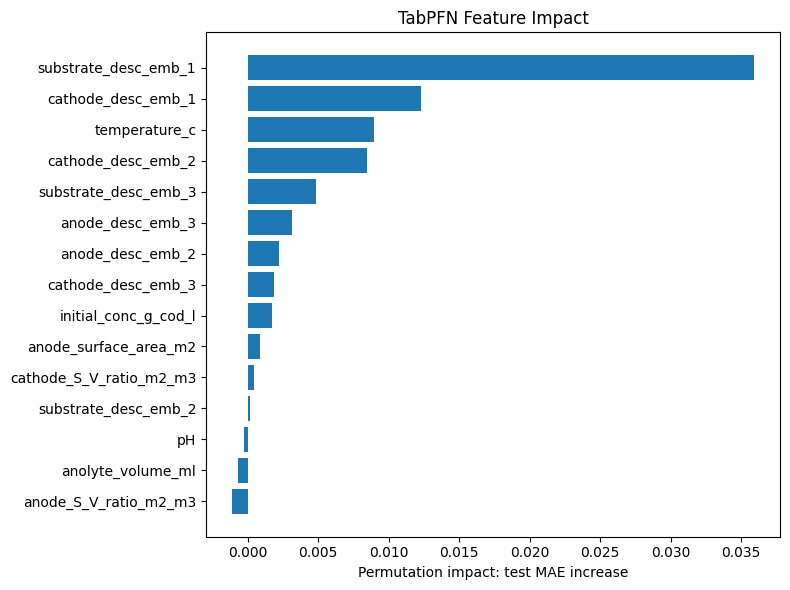

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
baseline_mae = mean_absolute_error(y_test, test_pred)
permutation_records = []

for feature in feature_cols:
    scores = []
    for repeat in range(PERMUTATION_REPEATS):
        X_perm = X_test.copy()
        X_perm[feature] = rng.permutation(X_perm[feature].to_numpy())
        perm_pred_model_scale = final_model.predict(X_perm.to_numpy(dtype=np.float32))
        perm_pred = inverse_transform_target(perm_pred_model_scale, TARGET_TRANSFORM, final_target_transformer)
        scores.append(mean_absolute_error(y_test, perm_pred) - baseline_mae)
    permutation_records.append({
        "feature": feature,
        "importance_mae_increase_mean": float(np.mean(scores)),
        "importance_mae_increase_std": float(np.std(scores, ddof=1)) if len(scores) > 1 else 0.0,
    })

importance_df = pd.DataFrame(permutation_records).sort_values("importance_mae_increase_mean", ascending=False).reset_index(drop=True)
importance_df.to_csv(RESULT_DIR / "feature_importance.csv", index=False, encoding="utf-8-sig")

display(importance_df.head(20))
fig, ax = plt.subplots(figsize=(8, 6))
top = importance_df.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance_mae_increase_mean"])
ax.set_xlabel("Permutation impact: test MAE increase")
ax.set_title("TabPFN Feature Impact")
fig.tight_layout()
fig.savefig(RESULT_DIR / "feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()